In [1]:
import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import sys
import glob
import pickle

# Add utils to path

from utils.GRC_helpers import plot_spike_shape_grand_average

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

%matplotlib widget

In [2]:
# Define data folder and figure save folder
data_folder = '../data'
data_folder = os.path.abspath(data_folder)
print(f'Data folder: {data_folder}')

figure_save_folder = '../figures/CKII_pooled'
figure_save_folder = os.path.abspath(figure_save_folder)
os.makedirs(figure_save_folder, exist_ok=True)
print(f'Figures will be saved to: {figure_save_folder}')

# Colors
color_map = {"in": "magenta", "out": "gray"}

Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled


In [3]:
# Find and load all spike_shapes_PF.pkl files
pattern = os.path.join(data_folder, 'CKII**', 'spike_shapes_PF.pkl')
pkl_files = glob.glob(pattern, recursive=True)
print(f'Found {len(pkl_files)} spike_shapes_PF files:')
for f in pkl_files:
    print(f'  {f}')

# Pool data from all datasets
grand_stack_pooled = {
    'simple': {'run_in': [], 'run_out': [], 'rest_in': [], 'rest_out': []},
    'complex': {'run_in': [], 'run_out': [], 'rest_in': [], 'rest_out': []},
}
time_ms_ref = None

for pkl_path in pkl_files:
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    
    time_ms = data['time_ms']
    grand_stack = data['grand_stack']
    
    if time_ms_ref is None:
        time_ms_ref = time_ms
    
    dataset_name = os.path.basename(os.path.dirname(pkl_path))
    cell_counts = {}
    
    for spike_type in ['simple', 'complex']:
        for cond in ['run_in', 'run_out', 'rest_in', 'rest_out']:
            waves = grand_stack.get(spike_type, {}).get(cond, [])
            for wave in waves:
                grand_stack_pooled[spike_type][cond].append(wave)
        cell_counts[spike_type] = len(grand_stack.get(spike_type, {}).get('run_in', []))
    
    print(f'Loaded {dataset_name}: simple={cell_counts["simple"]}, complex={cell_counts["complex"]} cells')

# Print summary
print(f'\nTotal pooled cells per condition:')
for spike_type in ['simple', 'complex']:
    for cond in ['run_in', 'run_out', 'rest_in', 'rest_out']:
        n = len(grand_stack_pooled[spike_type][cond])
        print(f'  {spike_type} - {cond}: {n} cells')

Found 3 spike_shapes_PF files:
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce21_PR_20250806/spike_shapes_PF.pkl
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce45_PX_20260118/spike_shapes_PF.pkl
  /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/data/CKII_pAce38_PX_20251126/spike_shapes_PF.pkl
Loaded CKII_pAce21_PR_20250806: simple=3, complex=3 cells
Loaded CKII_pAce45_PX_20260118: simple=4, complex=4 cells
Loaded CKII_pAce38_PX_20251126: simple=7, complex=7 cells

Total pooled cells per condition:
  simple - run_in: 14 cells
  simple - run_out: 14 cells
  simple - rest_in: 14 cells
  simple - rest_out: 14 cells
  complex - run_in: 14 cells
  complex - run_out: 14 cells
  complex - rest_in: 14 cells
  complex - rest_out: 14 cells


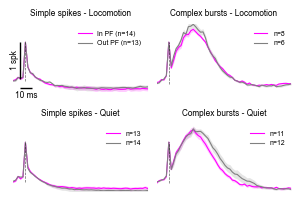

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_PlaceCell_analysis_V3/figures/CKII_pooled/SpikeShapes_PF_Grand_pooled.svg


In [4]:
# Plot pooled spike shape grand average (using GRC_helpers function)
out_path = os.path.join(figure_save_folder, 'SpikeShapes_PF_Grand_pooled.svg')
plot_spike_shape_grand_average(
    time_ms_ref,
    grand_stack_pooled,
    output_path=out_path,
    show=True,
)
print(f'Saved to {out_path}')

In [5]:
# Summary statistics
print('\n=== Summary Statistics ===')

for spike_type in ['simple', 'complex']:
    print(f'\n{spike_type.capitalize()} spikes:')
    for cond in ['run_in', 'run_out', 'rest_in', 'rest_out']:
        stack = grand_stack_pooled[spike_type][cond]
        if not stack:
            print(f'  {cond}: no data')
            continue
        arr = np.vstack(stack)
        valid_rows = np.any(np.isfinite(arr), axis=1)
        n_valid = int(np.sum(valid_rows))
        if n_valid > 0:
            mean_wave = np.nanmean(arr[valid_rows], axis=0)
            peak_idx = np.argmax(mean_wave)
            peak_val = mean_wave[peak_idx]
            peak_time = time_ms_ref[peak_idx]
            print(f'  {cond}: n={n_valid}, peak={peak_val:.3f} at t={peak_time:.1f}ms')
        else:
            print(f'  {cond}: n=0 (no valid data)')


=== Summary Statistics ===

Simple spikes:
  run_in: n=14, peak=1.000 at t=0.0ms
  run_out: n=13, peak=1.000 at t=0.0ms
  rest_in: n=13, peak=1.000 at t=0.0ms
  rest_out: n=14, peak=1.000 at t=0.0ms

Complex spikes:
  run_in: n=8, peak=1.353 at t=20.0ms
  run_out: n=6, peak=1.489 at t=20.0ms
  rest_in: n=11, peak=1.338 at t=20.0ms
  rest_out: n=12, peak=1.366 at t=20.0ms
